In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans, DBSCAN

In [2]:
plt.rcParams['font.family'] = "Malgun Gothic"

- 이미지 회색으로 바꾸는 거

In [3]:
people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = 1 # 답안용 전처리 : 타겟이 같은 것만 살리겠다는 의미

X_people = people.data[mask]
y_people = people.target[mask]
X_people = X_people / 255. # 이 과정들은 이미지를 회색으로 바꾸는 것

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=42)

In [ ]:
nmf = NMF(n_components=100, init='nndsvd', max_iter=1000, tol=1e-2, random_state=0)
nmf.fit(X_train)
pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)
X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_nmf = np.dot(nmf.transform(X_test), nmf.components_)
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)] # cluster_centers_ : 중점의 위치 좌표

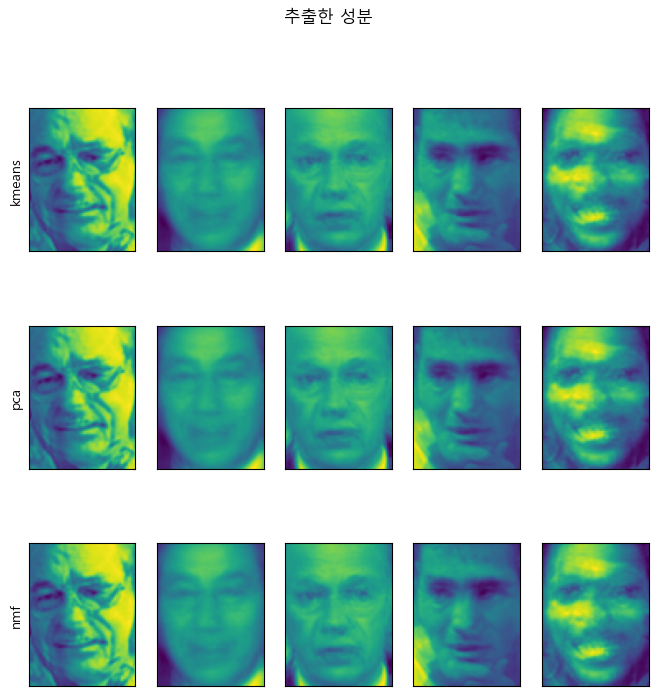

In [6]:
# zip(), enumerate()
fig, axes = plt.subplots(3, 5, figsize=(8,8), subplot_kw={'xticks':(), 'yticks':()})
fig.suptitle("추출한 성분")
image_shape = people.images[0].shape
for ax, comp_kmeans, comp_pca, comp_nmf in zip(axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[0].imshow(comp_kmeans.reshape(image_shape))
    ax[1].imshow(comp_kmeans.reshape(image_shape), cmap='viridis')
    ax[2].imshow(comp_kmeans.reshape(image_shape))

axes[0,0].set_ylabel("kmeans")
axes[1,0].set_ylabel("pca")
axes[2,0].set_ylabel("nmf")
plt.show()

Text(0, 0.5, 'nmf')

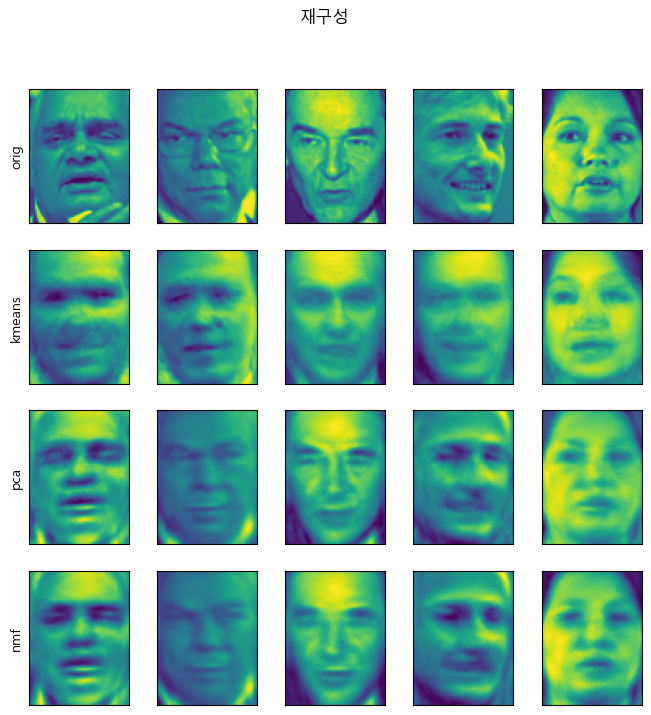

In [8]:
fig, axes = plt.subplots(4,5,subplot_kw={'xticks':(), 'yticks':()}, figsize=(8,8))
fig.suptitle("재구성")
for ax,orig, rec_kmeans, rec_pca, rec_nmf in zip(axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca, X_reconstructed_nmf):
    ax[0].imshow(orig.reshape(image_shape))
    ax[1].imshow(rec_kmeans.reshape(image_shape))
    ax[2].imshow(rec_pca.reshape(image_shape))
    ax[3].imshow(rec_nmf.reshape(image_shape))

axes[0,0].set_ylabel("orig")
axes[1,0].set_ylabel("kmeans")
axes[2,0].set_ylabel("pca")
axes[3,0].set_ylabel("nmf")